In [1]:
# Import Library
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Function

def preprocessing(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    gray = cv2.equalizeHist(gray)
    return gray

def init_detector(method):
    if method == 'SIFT':
        return cv2.SIFT_create()
    elif method == 'AKAZE':
        return cv2.AKAZE_create()
    elif method == 'ORB':
        return cv2.ORB_create()
    else:
        print("method gada yang terpilih!")

def init_flann(method):
    if method == 'SIFT':
        idxparam = dict(algorithm=1, trees=5)
    else:
        idxparam = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)

    srcparam = dict(checks=50)
    return cv2.FlannBasedMatcher(idxparam, srcparam)

In [18]:
TARGET_DIR = 'images/target/'
SOURCE_DIR = 'images/source/'

METHODS = ['SIFT', 'AKAZE', 'ORB']
LOWE_RATIO = [0.45, 0.5, 0.55]

# Data target
target_path = TARGET_DIR + 'wakamo.png'
target = cv2.imread(target_path)
print("Shape: ", target.shape)

# Data source
source_data = []
for fname in os.listdir(SOURCE_DIR):
    fname = SOURCE_DIR + fname
    fname = cv2.imread(fname)
    source_data.append(fname)

print("Source Data: ", len(source_data))

Shape:  (267, 529, 3)
Source Data:  12


In [19]:
target_gray = preprocessing(target)

best_matches = 0
best_matches_data = None
best_method = None
best_ratio = None

for method in METHODS:
    print("Method: ", method)

    detector = init_detector(method)
    target_kp, target_desc = detector.detectAndCompute(target_gray, None)
    target_desc = np.float32(target_desc) if method == 'SIFT' else np.uint8(target_desc)

    for ratio in LOWE_RATIO:
        print("  Lowe Ratio: ", ratio)

        for idx, img in enumerate(source_data):
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            source_gray = preprocessing(img)
            source_kp, source_desc = detector.detectAndCompute(source_gray, None)
            source_desc = np.float32(source_desc) if method == 'SIFT' else np.uint8(source_desc)

            # FLANN MATCHER

            flann = init_flann(method)
            matches = flann.knnMatch(target_desc, source_desc, k=2)
            matchesmask = [[0, 0] for _ in range(len(matches))]
            curr_matches = 0

            # Lowe's Ratio

            for i, pair in enumerate(matches):
                if len(pair) == 2:
                    fm, sm = pair
                    if fm.distance < ratio * sm.distance:
                        matchesmask[i] = [1, 0]
                        curr_matches += 1
            
            # print progeress
            print(" ", os.listdir(SOURCE_DIR)[idx], ":", curr_matches, "good matches")

            if curr_matches > best_matches:
                best_matches = curr_matches
                best_method = method
                best_ratio = ratio
                best_matches_data = {
                    'image_data'    : img_rgb,
                    'keypoint'      : source_kp,
                    'descriptor'    : source_desc,
                    'matches'       : matches,
                    'matchesmask'   : matchesmask,
                    'filename'      : os.listdir(SOURCE_DIR)[idx],
                    'target_kp'     : target_kp
                }


Method:  SIFT
  Lowe Ratio:  0.45
  plana.png : 0 good matches
  wakamo.png : 217 good matches
  hoshino.png : 0 good matches
  cherino.png : 0 good matches
  hikari.png : 0 good matches
  hina.png : 0 good matches
  yuuka.png : 0 good matches
  shiroko.png : 0 good matches
  misaki.png : 0 good matches
  miyako.png : 0 good matches
  kisaki.png : 0 good matches
  mika.png : 0 good matches
  Lowe Ratio:  0.5
  plana.png : 0 good matches
  wakamo.png : 241 good matches
  hoshino.png : 0 good matches
  cherino.png : 0 good matches
  hikari.png : 0 good matches
  hina.png : 0 good matches
  yuuka.png : 0 good matches
  shiroko.png : 0 good matches
  misaki.png : 0 good matches
  miyako.png : 0 good matches
  kisaki.png : 0 good matches
  mika.png : 0 good matches
  Lowe Ratio:  0.55
  plana.png : 0 good matches
  wakamo.png : 260 good matches
  hoshino.png : 0 good matches
  cherino.png : 0 good matches
  hikari.png : 0 good matches
  hina.png : 0 good matches
  yuuka.png : 0 good matches

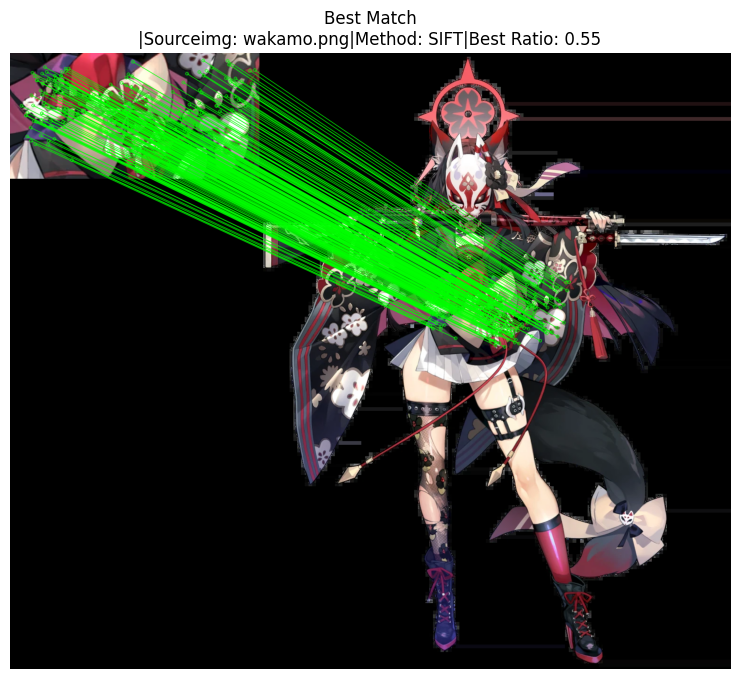


Best Method    : SIFT
Best Lowe Ratio  : 0.55
Best Source Image: wakamo.png
Good Matches     : 260


In [20]:
# show best result

target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

if best_matches_data is not None:
    result = cv2.drawMatchesKnn(
        target_rgb,
        best_matches_data['target_kp'],
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['matches'],
        None,
        matchesMask=best_matches_data['matchesmask'],
        matchColor=[0,255,0],
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16,8))
    plt.imshow(result)
    plt.title("Best Match\n"
            + "|Sourceimg: " + best_matches_data['filename']
            + "|Method: " + best_method
            + "|Best Ratio: " + str(best_ratio)
            )
    plt.axis('off')
    plt.show()

    print("\nBest Method    :", best_method)
    print("Best Lowe Ratio  :", best_ratio)
    print("Best Source Image:", best_matches_data['filename'])
    print("Good Matches     :", best_matches)

else:
    print("Tiak ada matching yang berhasil ditemukan")

